# 06: CRINK Network

Data: crink_bilateral_2024
Period: 2024
N: 7 dyads
Result: CHN→RUS 245 Bn. Total 300 Bn. Asymmetry IRN-RUS 4.38.

In [1]:
# ============================================================
# Setup
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (12, 6), "font.size": 11})

_candidates = [Path.cwd(), Path.cwd().parent]
for c in _candidates:
    _proj = c / "russia_china_dependency"
    if _proj.exists() and (_proj / "02_processed_data").exists():
        PROJECT_ROOT = c
        break
else:
    PROJECT_ROOT = Path.cwd()

PROCESSED = PROJECT_ROOT / "russia_china_dependency" / "02_processed_data"
FIGURES = PROJECT_ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

print("Setup OK |", FIGURES)

Setup OK | d:\Users\Proprietaire\Desktop\Projet_perso\Chine-russie\reports\figures


In [2]:
# ============================================================
# Load CRINK data + compute asymmetry
# ============================================================

import sys
sys.path.insert(0, str(PROJECT_ROOT))
from russia_china_dependency.analysis.asymmetry import compute_asymmetry_matrix, build_total_trade

crink = pd.read_csv(PROCESSED / "crink_bilateral_2024.csv")
total_trade = build_total_trade(crink_only=False)
asymmetry_matrix = compute_asymmetry_matrix(crink, total_trade)

print("CRINK bilateral flows:")
print(crink.to_string(index=False))
print("\nAsymmetry (row=exporter, col=importer; >1 = exporter more dependent on importer):")
print(asymmetry_matrix.round(2).to_string())

CRINK bilateral flows:
exporter importer  value_bn  category            source
     CHN      RUS     245.0     trade     comtrade_2024
     CHN      IRN      42.0 trade+oil         csis_2024
     CHN      PRK       1.0     trade         tass_2024
     RUS      IRN       5.0      arms    sipri_estimate
     RUS      PRK       1.0 munitions       us_estimate
     IRN      RUS       3.0    drones         oryx_2024
     PRK      RUS       2.5 munitions pentagon_estimate

Asymmetry (row=exporter, col=importer; >1 = exporter more dependent on importer):
     CHN   IRN   PRK     RUS
CHN  NaN  0.02  0.00    0.10
IRN  inf   NaN   inf    4.38
PRK  inf   inf   NaN  116.67
RUS  inf  0.14  0.01     NaN


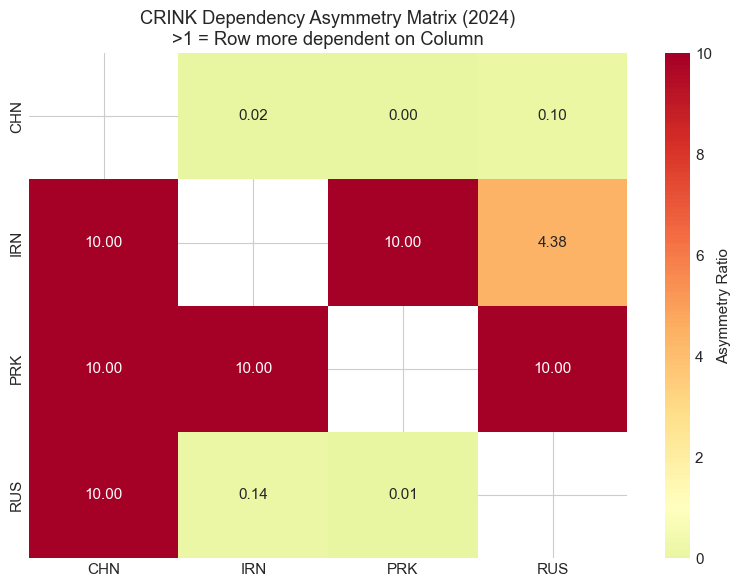

In [3]:
# ============================================================
# Asymmetry heatmap
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))
masked = asymmetry_matrix.astype(float).clip(0, 10)
masked = masked.replace(0, np.nan).replace(np.inf, np.nan)
sns.heatmap(masked, annot=True, fmt=".2f", cmap="RdYlGn_r", center=1, vmin=0, vmax=10,
            cbar_kws={"label": "Asymmetry Ratio"}, ax=ax)
ax.set_title("CRINK Dependency Asymmetry Matrix (2024)\n>1 = Row more dependent on Column")
plt.tight_layout()
plt.savefig(FIGURES / "crink_asymmetry_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

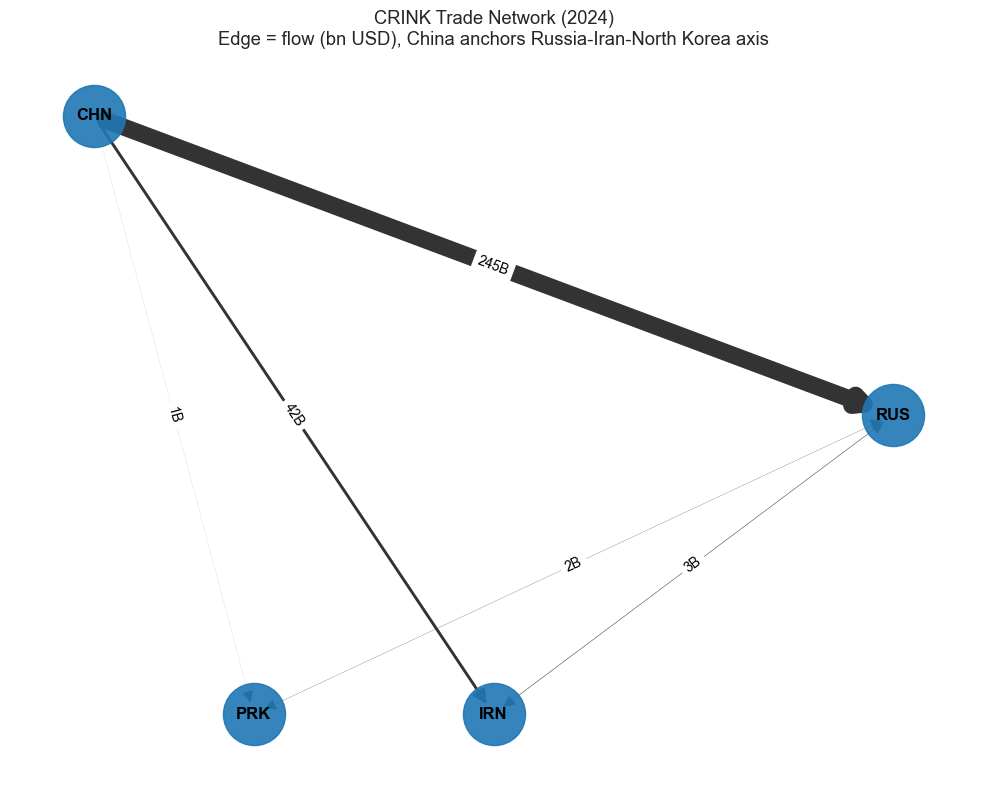

In [4]:
# ============================================================
# CRINK directed network graph
# ============================================================

G = nx.DiGraph()
for _, row in crink.iterrows():
    G.add_edge(row["exporter"], row["importer"], weight=row["value_bn"])

# Layout
pos = {"CHN": (0, 1), "RUS": (1, 0.5), "IRN": (0.5, 0), "PRK": (0.2, 0)}

fig, ax = plt.subplots(figsize=(10, 8))
edges = G.edges()
weights = [G[u][v]["weight"] for u, v in edges]
widths = [w / 20 for w in weights]

nx.draw_networkx_nodes(G, pos, node_size=2000, node_color="#1f77b4", alpha=0.9, ax=ax)
nx.draw_networkx_edges(G, pos, width=widths, edge_color="#333", arrows=True, arrowsize=20, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight="bold", ax=ax)

# Edge labels (value_bn)
edge_labels = {(u, v): f"{G[u][v]['weight']:.0f}B" for u, v in edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=10, ax=ax)

ax.set_title("CRINK Trade Network (2024)\nEdge = flow (bn USD), China anchors Russia-Iran-North Korea axis")
ax.axis("off")
plt.tight_layout()
plt.savefig(FIGURES / "crink_network_graph.png", dpi=150, bbox_inches="tight")
plt.show()

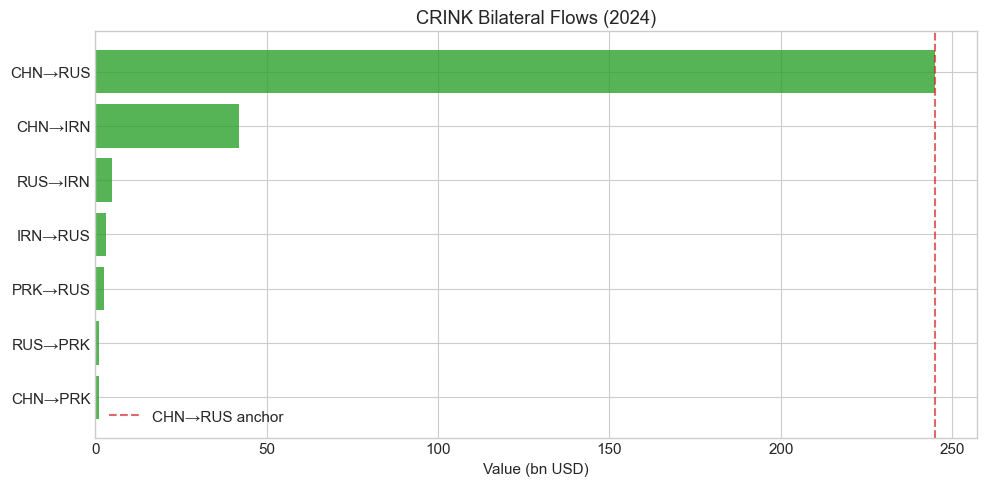

Total CRINK-internal flows: 300 bn USD


In [5]:
# ============================================================
# Bar chart: flows by dyad
# ============================================================

crink["dyad"] = crink["exporter"] + "→" + crink["importer"]
crink_sorted = crink.sort_values("value_bn", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(crink_sorted["dyad"], crink_sorted["value_bn"], color="#2ca02c", alpha=0.8)
ax.axvline(245, color="#d62728", linestyle="--", alpha=0.7, label="CHN→RUS anchor")
ax.set_xlabel("Value (bn USD)")
ax.set_title("CRINK Bilateral Flows (2024)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "crink_flows_bars.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Total CRINK-internal flows: {crink['value_bn'].sum():.0f} bn USD")